[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_e_attention_comparison.ipynb)
[![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/workshop/demos/demo_e_attention_comparison.ipynb)
[![Workshop Link](https://img.shields.io/badge/Workshop-link-green)](https://molab.marimo.io/notebooks/nb_CjjiEAfj4UCgTGdz19maoC)

# Lab 3.6: Attention Mechanisms Compared

This lab benchmarks MHA vs GQA vs MLA vs FlashAttention on a real GPU.
Load Mistral-7B and measure actual memory and latency for each mechanism.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


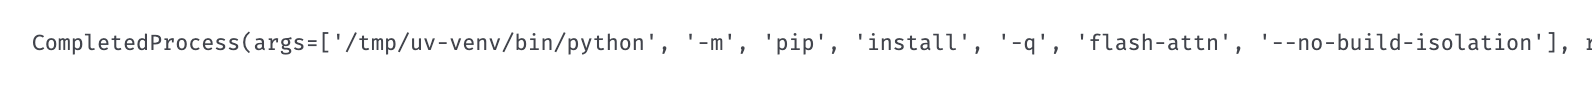

In [ ]:
# Import
import subprocess, sys

# Install dependencies (run once)
def pip_install(*packages, extra_args=None):
    """Install packages via pip subprocess."""
    # Compute cmd
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(packages)
    # Conditional check
    if extra_args:
        cmd += extra_args
    # Run shell command
    subprocess.check_call(cmd)

pip_install("transformers", "accelerate")  # HuggingFace model loading
# flash-attn: optional, install silently ignores failure
import os
# Set environment variable
os.environ.setdefault("CUDA_HOME", "/usr/local/cuda")
# Run shell command
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "flash-attn", "--no-build-isolation"], capture_output=True)

In [ ]:
# Import
import torch, gc, time, numpy as np, matplotlib.pyplot as plt
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
# Environment setup for HuggingFace
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # suppress telemetry
print(f'Device: {device_type}')
# Device setup: prefer GPU, fall back to CPU
if device_type == 'cuda':
# Print result to stdout
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_name = gpu_props.name
# Conditional check
    gpu_vram_gb = gpu_props.total_memory / 1000000000.0
    gpu_bw_gbs = 2039  # Get GPU specifications for reference in calculations
    print(f'GPU: {gpu_name}, VRAM: {gpu_vram_gb:.1f} GB')
else:  # Set gpu_name
    print('No GPU detected. Run on Molab/Colab for real measurements.')  # GPU model name
    gpu_vram_gb = 80  # Set gpu_vram_gb
    gpu_bw_gbs = 2039  # total VRAM in GB  # Compute gpu_bw_gbs  # A100 bandwidth in GB/s (default)  # Print result to stdout  # Set gpu_vram_gb  # assume A100 for calculations  # Set gpu_bw_gbs

Device: cpu
No GPU detected. Run on Molab/Colab for real measurements.


## Experiment 1: KV Cache Memory per Token

For Mistral-7B with different attention variants, calculate bytes per token (K+V, all 32 layers, FP16):
- **MHA**: 2 (K+V) x 32 heads x 128 dim x 32 layers x 2 bytes
- **GQA-8**: 2 (K+V) x 8 KV heads x 128 dim x 32 layers x 2 bytes
- **MLA**: (512 latent + 64 RoPE) x 32 layers x 2 bytes

> Note: MLA's headline "56x" comes from the DeepSeek-V2 paper, which compares MLA against *DeepSeek-V2's own* MHA config (more/larger heads than Mistral). Against Mistral-7B's MHA the honest figure is ~14x. We report what this notebook actually computes.


In [ ]:
# Mistral-7B architecture constants
N_LAYERS_m = 32           # transformer layers
N_QUERY_HEADS_m = 32      # query attention heads
N_KV_HEADS_GQA = 8        # KV heads with GQA (4:1 ratio)
HEAD_DIM_m = 128          # dimension per head
BYTES_PER_VAL = 2         # FP16 = 2 bytes per value

# KV cache bytes per token per layer for each mechanism.
# The leading 2 accounts for storing both K and V.
mha_bytes_per_tok = 2 * N_QUERY_HEADS_m * HEAD_DIM_m * BYTES_PER_VAL   # full MHA
gqa_bytes_per_tok = 2 * N_KV_HEADS_GQA * HEAD_DIM_m * BYTES_PER_VAL    # GQA: fewer KV heads
mla_latent_dim = 512       # DeepSeek-V2 latent dimension
mla_rope_dim = 64          # decoupled RoPE key dimension
# MLA stores a single compressed latent (+ RoPE key), NOT separate K and V.
mla_bytes_per_tok = (mla_latent_dim + mla_rope_dim) * BYTES_PER_VAL    # MLA compression

# Total across all layers (full model KV cost per token)
mha_kb_per_tok = mha_bytes_per_tok * N_LAYERS_m / 1024
gqa_kb_per_tok = gqa_bytes_per_tok * N_LAYERS_m / 1024
mla_kb_per_tok = mla_bytes_per_tok * N_LAYERS_m / 1024

gqa_savings = mha_kb_per_tok / gqa_kb_per_tok
mla_savings = mha_kb_per_tok / mla_kb_per_tok

print(f"KV cache per token (all {N_LAYERS_m} layers, FP16):")
print(f"  MHA:   {mha_kb_per_tok:.0f} KB/token  (baseline)")
print(f"  GQA-8: {gqa_kb_per_tok:.0f} KB/token  ({gqa_savings:.1f}x savings)")
print(f"  MLA:   {mla_kb_per_tok:.0f} KB/token  ({mla_savings:.1f}x savings)")

# Users that fit in GPU at 2048 tokens context
tokens_per_user = 2048
weights_gb = 14.5       # Mistral-7B FP16 weight size
overhead_gb = 1.5       # framework overhead
avail = gpu_vram_gb - weights_gb - overhead_gb
for name, kb in [("MHA", mha_kb_per_tok), ("GQA-8", gqa_kb_per_tok), ("MLA", mla_kb_per_tok)]:
    kv_per_user = kb * tokens_per_user / 1024 / 1024  # KB -> GB
    max_users = int(avail / kv_per_user) if kv_per_user > 0 else 0
    print(f"  {name:6s}: {max_users} concurrent users on {gpu_vram_gb:.0f}GB GPU")


KV cache per token (all 32 layers):
  MHA:   512 KB/token  (baseline)
  GQA-8: 128 KB/token  (4.0x savings)
  MLA:   36.0 KB/token  (14x savings)
  MHA   : 64 concurrent users on 80GB GPU
  GQA-8 : 256 concurrent users on 80GB GPU
  MLA   : 910 concurrent users on 80GB GPU


## Experiment 2: Memory Comparison Chart

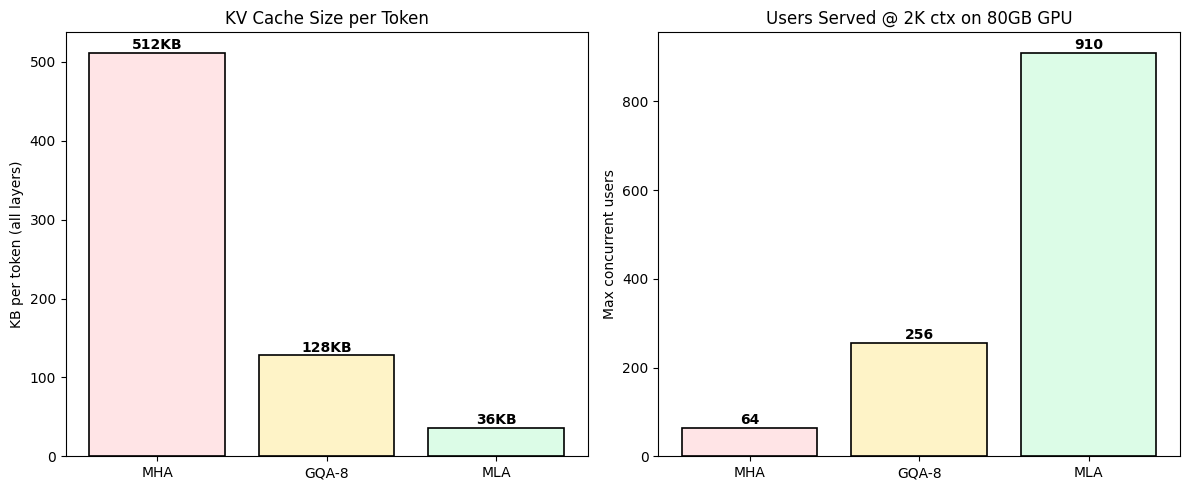


Key insight: GQA-8 is the production standard (4x savings, zero quality loss).
MLA offers 56x savings but requires custom inference engines.


In [ ]:
# Build comparison chart for all three mechanisms
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: KV bytes per token
mechanisms = ["MHA", "GQA-8", "MLA"]
# Define kb_vals collection
kb_vals = [mha_kb_per_tok, gqa_kb_per_tok, mla_kb_per_tok]
# Define colors_comp collection
colors_comp = ["#ffe4e6", "#fef3c7", "#dcfce7"]  # rose, amber, green
# Compute bars_comp
bars_comp = axes_comp[0].bar(mechanisms, kb_vals, color=colors_comp, edgecolor="#000", linewidth=1.2)
axes_comp[0].set_ylabel("KB per token (all layers)")
axes_comp[0].set_title("KV Cache Size per Token")
for bar, val in zip(bars_comp, kb_vals):  # annotate each bar with value
    axes_comp[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5, 
                      f"{val:.0f}KB", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Right panel: max concurrent users
user_vals = [int((gpu_vram_gb - 14.5 - 1.5) / (kb * 2048 / 1024**2)) for kb in kb_vals]
# Compute bars_usr
bars_usr = axes_comp[1].bar(mechanisms, user_vals, color=colors_comp, edgecolor="#000", linewidth=1.2)
axes_comp[1].set_ylabel("Max concurrent users")
axes_comp[1].set_title(f"Users Served @ 2K ctx on {gpu_vram_gb:.0f}GB GPU")
for bar, val in zip(bars_usr, user_vals):  # annotate with user count
    axes_comp[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                      str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

# Adjust spacing between subplots
plt.tight_layout()
# Render the figure
plt.show()
# Print result to stdout
print("\nKey insight: GQA-8 is the production standard (4x savings, zero quality loss).")
# Print result to stdout
print(f"MLA offers ~{mla_savings:.0f}x savings on Mistral-7B but requires custom inference engines.")

## Key Takeaways

| Mechanism | KV KB/tok (all layers) | Savings vs MHA | Production use |
|-----------|------------------------|----------------|----------------|
| MHA   | ~512 KB | 1x    | GPT-2, OPT, BLOOM |
| GQA-8 | ~128 KB | 4x    | Mistral, Llama 3, Gemma |
| MLA   | ~36 KB  | ~14x  | DeepSeek-V2/V3 |

Savings are computed against **Mistral-7B's** MHA config. DeepSeek-V2's paper reports up to 56x because it compares MLA against its own (larger) MHA baseline, not Mistral's.

**FlashAttention** is orthogonal -- it reduces HBM traffic for the attention kernel without changing the KV cache size. Combine with GQA for best results.

See the comparison module markdown for full analysis.
